# WR Ceiling Diagnostic — Per-Tier Evaluation

**Hipoteza:** Svi modeli konvergiraju u ~17.7-18.5 MAE zato sto **jedan podskup WR-eva** (low-volume
role players, benchwarmers, blowout situacije sa 0-5 yards) unosi nesrazmerno veliku gresku. Elite /
volume WR-evi su mozda daleko predvidljiviji nego sto globalna MAE otkriva.

**Eksperiment:** Svaki test sample dobija **tier** na osnovu `trailing_career_avg` (srednji receiving
yards kroz sve PROSLE igre pre current-a; zero-leakage). Kvartilne granice se racunaju iz training seta.

Tieri:
- **Q1 fringe**: bottom 25% — rookies, deep-depth, benchwarmers
- **Q2 role**: WR3/WR4 players
- **Q3 starter**: WR2 / high-variance WR1
- **Q4 volume**: elite WR1 — produkcija >75th percentile career avg

**Sta ocekujemo:** Q4 MAE ce biti **veci u apsolutnim jardima** (jer ti igraci imaju vece volume),
ali relativno (MAE/mean_yards) ce biti **manji**. Q1 ce imati **visok apsolutni MAE** u odnosu na
svoje male brojeve (zbog efekata zero-inflation i "breakout game" outlier-a).

Ovo je diagnostic — ne menjamo model pipeline, samo razbijamo test error po grupama.


---
## 1. Imports


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, json, time, random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input
from tensorflow.keras.layers import (
    Dense, Dropout, LayerNormalization, GaussianNoise,
    LSTM, GRU, Bidirectional, Masking, Concatenate,
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow {tf.__version__}')


TensorFlow 2.21.0


---
## 2. Feature Engineering


In [2]:
df = pd.read_csv('../data/fully combined/wr_all_weeks.csv')
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)

work_df = df.copy()

wp_rename_map = {
    'yards_wp_<25':       'yards_wp_less_than_25',
    'yards_wp_>75':       'yards_wp_greater_than_75',
    'receptions_wp_<25':  'receptions_wp_less_than_25',
    'receptions_wp_>75':  'receptions_wp_greater_than_75',
    'targets_wp_<25':     'targets_wp_less_than_25',
    'targets_wp_>75':     'targets_wp_greater_than_75',
}
work_df = work_df.rename(columns={k: v for k, v in wp_rename_map.items() if k in work_df.columns})

work_df['player_team_inferred'] = np.where(
    (work_df['home_team'] == work_df['defteam']) & (work_df['away_team'] != work_df['defteam']),
    work_df['away_team'],
    np.where(
        (work_df['away_team'] == work_df['defteam']) & (work_df['home_team'] != work_df['defteam']),
        work_df['home_team'], np.nan,
    ),
)
prev_team = work_df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
work_df['team_changed'] = (
    work_df['player_team_inferred'].notna()
    & prev_team.notna()
    & (work_df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = work_df.groupby('receiver_player_id')['season'].shift(1)
work_df['is_new_season'] = (prev_season.notna() & (work_df['season'] != prev_season)).astype(int)

work_df['season_week_abs'] = (work_df['season'] - 2015) * 22 + work_df['week']
work_df['weeks_since_last_game'] = (
    work_df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
work_df.drop(columns=['season_week_abs'], inplace=True)

season_career = (
    work_df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(avg_yards=('receiving_yards', 'mean'),
         avg_target_share=('target_share', 'mean'),
         avg_epa=('epa', 'mean'),
         avg_air_yard_share=('air_yard_share', 'mean'),
         avg_catch_rate=('catch_rate', 'mean'),
         games_played=('game_id', 'count'))
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [f'{c}_last_season' for c in
               ['avg_yards', 'avg_target_share', 'avg_epa',
                'avg_air_yard_share', 'avg_catch_rate', 'games_played']]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
work_df = work_df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
work_df[career_cols] = work_df[career_cols].fillna(0)

rolling_source_cols = [
    'targets', 'receptions', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'catch_rate',
    'avg_depth', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs',
    'yards_per_target', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share',
    'target_share', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct',
    'avg_score_diff', 'trailing_pct', 'leading_pct', 'avg_quarter', 'success_rate',
    'big_play_rate', 'avg_start_yardline', 'red_zone_targets', 'end_zone_targets',
    'third_down_targets', 'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets', 'wp_var', 'target_share_std',
    'reception_std', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev',
    'def_epa_dev', 'yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4',
    'receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4',
    'targets_Q1', 'targets_Q2', 'targets_Q3', 'targets_Q4',
    'lost_yards_due_to_penalty',
    'yards_wp_less_than_25', 'yards_wp_25_45', 'yards_wp_45_55',
    'yards_wp_55_75', 'yards_wp_greater_than_75',
    'receptions_wp_less_than_25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_greater_than_75',
    'targets_wp_less_than_25', 'targets_wp_25_45', 'targets_wp_45_55',
    'targets_wp_55_75', 'targets_wp_greater_than_75',
    'weeks_since_last_game',
]
available_roll_cols = [c for c in rolling_source_cols if c in work_df.columns]
grp = work_df.groupby('receiver_player_id', sort=False)
derived_cols = []
for col in available_roll_cols:
    work_df[f'{col}_lag1']  = grp[col].transform(lambda s: s.shift(1))
    work_df[f'{col}_roll5'] = grp[col].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )
    derived_cols.extend([f'{col}_lag1', f'{col}_roll5'])

momentum_sources = [
    'targets', 'receptions', 'air_yards', 'epa', 'catch_rate',
    'target_share', 'yards_per_target', 'air_yard_share',
]
momentum_cols = []
for col in momentum_sources:
    lag1_col, roll5_col = f'{col}_lag1', f'{col}_roll5'
    if lag1_col in work_df.columns and roll5_col in work_df.columns:
        mcol = f'{col}_momentum'
        work_df[mcol] = work_df[lag1_col] - work_df[roll5_col]
        momentum_cols.append(mcol)

interaction_cols = []
if 'target_share_lag1' in work_df.columns:
    work_df['target_volume_interaction'] = (
        work_df['target_share_lag1'] * work_df['pregame_total']
    )
    interaction_cols.append('target_volume_interaction')

pregame_features = [
    'pregame_spread', 'pregame_total', 'surface', 'is_dome', 'temp_f',
    'humidity_pct', 'wind_mph', 'is_rain', 'is_snow', 'is_clear',
    'season', 'week', 'team_changed', 'is_new_season',
]
all_feature_columns = (
    pregame_features + career_cols + derived_cols + momentum_cols + interaction_cols
)

model_df = work_df.copy()
lag1_all = [c for c in all_feature_columns if c.endswith('_lag1')]
model_df = model_df.loc[~model_df[lag1_all].isna().all(axis=1)].copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated()]
model_df[all_feature_columns] = model_df[all_feature_columns].fillna(0)
model_df['receiving_yards_sqrt'] = np.sqrt(model_df['receiving_yards'].clip(lower=0))

model_df = model_df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)
print(f'Dataset: {model_df.shape}  |  engineered features: {len(all_feature_columns)}')


Dataset: (44396, 272)  |  engineered features: 181


---
## 3. Top-10 Features + Season Split


In [3]:
selected_features = [
    'first_downs_roll5',
    'target_share_std_lag1',
    'targets_roll5',
    'air_yards_roll5',
    'pregame_total',
    'avg_yards_last_season',
    'avg_start_yardline_roll5',
    'wind_mph',
    'target_share_std_roll5',
    'air_yard_share_roll5',
]

missing = [f for f in selected_features if f not in model_df.columns]
if missing:
    raise ValueError(f'Missing top-10 features: {missing}')

train_seasons = list(range(2015, 2022))
val_seasons   = [2022, 2023]
test_seasons  = [2024, 2025]

train_mask_df = model_df['season'].isin(train_seasons)
val_mask_df   = model_df['season'].isin(val_seasons)
test_mask_df  = model_df['season'].isin(test_seasons)

print(f'rows: train={train_mask_df.sum()}  val={val_mask_df.sum()}  test={test_mask_df.sum()}')
print(f'features: top-10 ({len(selected_features)})')


rows: train=29276  val=8921  test=6199
features: top-10 (10)


---
## 4. Raw Target Setup


In [4]:
# Standard raw target (no smoothing)
model_df['target_raw']      = model_df['receiving_yards']
model_df['target_raw_sqrt'] = model_df['receiving_yards_sqrt']


---
## 4b. Tier Assignment


In [5]:
# Trailing career average per player (no leakage — uses only past games).
# This is the tier-assignment key.
model_df['trailing_career_avg'] = (
    model_df.groupby('receiver_player_id')['receiving_yards']
    .transform(lambda s: s.shift(1).expanding().mean())
)
# First-ever game of a player has NaN — fill with 0 (treats rookie as fringe tier)
model_df['trailing_career_avg'] = model_df['trailing_career_avg'].fillna(0)

# Compute quartile thresholds on TRAINING data only (no test leakage)
train_tca = model_df.loc[train_mask_df, 'trailing_career_avg'].values
q1, q2, q3 = np.quantile(train_tca, [0.25, 0.5, 0.75])
print(f'Trailing-career-avg quartile cutoffs (from train):')
print(f'  Q1 (fringe)  : <= {q1:.1f} yds/game')
print(f'  Q2 (role)    : {q1:.1f} - {q2:.1f}')
print(f'  Q3 (starter) : {q2:.1f} - {q3:.1f}')
print(f'  Q4 (volume)  : > {q3:.1f}')


def assign_tier(x):
    if x <= q1: return 'Q1_fringe'
    if x <= q2: return 'Q2_role'
    if x <= q3: return 'Q3_starter'
    return 'Q4_volume'

model_df['tier'] = model_df['trailing_career_avg'].apply(assign_tier)
print()
print('Tier distribution on test seasons:')
print(model_df.loc[test_mask_df, 'tier'].value_counts().sort_index().to_string())


Trailing-career-avg quartile cutoffs (from train):
  Q1 (fringe)  : <= 15.2 yds/game
  Q2 (role)    : 15.2 - 25.7
  Q3 (starter) : 25.7 - 42.3
  Q4 (volume)  : > 42.3

Tier distribution on test seasons:
tier
Q1_fringe     1486
Q2_role       1694
Q3_starter    1505
Q4_volume     1514


---
## 4c. Split + Scaler


In [6]:
train_df = model_df[train_mask_df].copy()
val_df   = model_df[val_mask_df].copy()
test_df  = model_df[test_mask_df].copy()

y_train_sqrt = train_df['target_raw_sqrt'].values
y_val_sqrt   = val_df['target_raw_sqrt'].values
y_test_sqrt  = test_df['target_raw_sqrt'].values

# Main target in original units
y_train_main = train_df['target_raw'].values
y_val_main   = val_df['target_raw'].values
y_test_main  = test_df['target_raw'].values

# Raw target (for smoothed notebook: diagnostic comparison; for raw: same as main)
y_train_raw = train_df['target_raw'].values
y_val_raw   = val_df['target_raw'].values
y_test_raw  = test_df['target_raw'].values

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[selected_features].values)
X_val   = scaler.transform(val_df[selected_features].values)
X_test  = scaler.transform(test_df[selected_features].values)

mean_y_train = np.mean(np.clip(y_train_main, 0, None))
sw_train = 1.0 + 0.6 * np.sqrt(np.clip(y_train_main, 0, None) / mean_y_train)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Sample weights: [{sw_train.min():.2f}, {sw_train.max():.2f}]')


Train: (29276, 10)  Val: (8921, 10)  Test: (6199, 10)
Sample weights: [1.00, 2.87]


---
## 5. Utilities


In [7]:
def eval_preds(y_true, y_pred):
    return {
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2':   float(r2_score(y_true, y_pred)),
    }

def sqrt_to_orig(p):
    return np.clip(p, 0, None) ** 2

predictions = {}   # name -> {'val': array, 'test': array} (in original yard units)
results = {}       # name -> metric dicts

def log_result(name, val_metrics, test_metrics, seconds=None):
    results[name] = {'val': val_metrics, 'test': test_metrics, 'seconds': seconds}
    s = f' ({seconds:.0f}s)' if seconds is not None else ''
    print(f'{name:<22}{s:>10}  val MAE={val_metrics["MAE"]:.3f}  '
          f'test MAE={test_metrics["MAE"]:.3f}  R2={test_metrics["R2"]:.4f}')


---
## 6. Tabular Models


In [8]:
# --- 5.1 RandomForest
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=4,
    random_state=SEED, n_jobs=-1,
)
rf.fit(X_train, y_train_sqrt, sample_weight=sw_train)
rf_val  = sqrt_to_orig(rf.predict(X_val))
rf_test = sqrt_to_orig(rf.predict(X_test))
predictions['RandomForest'] = {'val': rf_val, 'test': rf_test}
log_result('RandomForest',
           eval_preds(y_val_main,  rf_val),
           eval_preds(y_test_main, rf_test),
           time.time() - t0)

# --- 5.2 XGBoost
t0 = time.time()
xgb = XGBRegressor(
    n_estimators=800, max_depth=6, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    min_child_weight=4, gamma=0.1,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, tree_method='hist', verbosity=0,
)
xgb.fit(X_train, y_train_sqrt, sample_weight=sw_train,
        eval_set=[(X_val, y_val_sqrt)], verbose=False)
xgb_val  = sqrt_to_orig(xgb.predict(X_val))
xgb_test = sqrt_to_orig(xgb.predict(X_test))
predictions['XGBoost'] = {'val': xgb_val, 'test': xgb_test}
log_result('XGBoost',
           eval_preds(y_val_main,  xgb_val),
           eval_preds(y_test_main, xgb_test),
           time.time() - t0)

# --- 5.3 LightGBM
t0 = time.time()
lgb = LGBMRegressor(
    n_estimators=1000, num_leaves=63, learning_rate=0.03,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
    random_state=SEED, verbosity=-1,
)
lgb.fit(X_train, y_train_sqrt, sample_weight=sw_train,
        eval_set=[(X_val, y_val_sqrt)])
lgb_val  = sqrt_to_orig(lgb.predict(X_val))
lgb_test = sqrt_to_orig(lgb.predict(X_test))
predictions['LightGBM'] = {'val': lgb_val, 'test': lgb_test}
log_result('LightGBM',
           eval_preds(y_val_main,  lgb_val),
           eval_preds(y_test_main, lgb_test),
           time.time() - t0)

# --- 5.4 ElasticNet
t0 = time.time()
enet = ElasticNet(alpha=0.01, l1_ratio=0.3, max_iter=20000, random_state=SEED)
enet.fit(X_train, y_train_sqrt, sample_weight=sw_train)
enet_val  = sqrt_to_orig(enet.predict(X_val))
enet_test = sqrt_to_orig(enet.predict(X_test))
predictions['ElasticNet'] = {'val': enet_val, 'test': enet_test}
log_result('ElasticNet',
           eval_preds(y_val_main,  enet_val),
           eval_preds(y_test_main, enet_test),
           time.time() - t0)


RandomForest                (8s)  val MAE=18.224  test MAE=17.898  R2=0.3247
XGBoost                     (6s)  val MAE=18.315  test MAE=18.049  R2=0.3111
LightGBM                    (6s)  val MAE=18.525  test MAE=18.202  R2=0.2940
ElasticNet                  (0s)  val MAE=18.531  test MAE=18.190  R2=0.3101


In [9]:
MODEL_B_PARAMS = {
    'n_layers': 5,
    'units': [448, 128, 320, 448, 256],
    'dropout': 0.5,
    'huber_delta': 0.5,
    'lr': 0.003701177981657943,
    'weight_decay': 1.5007044511603625e-05,
    'batch_size': 32,
}

def build_hybrid_mlp(input_dim, params, loss_fn, noise_stddev=0.15):
    model = keras.Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(GaussianNoise(noise_stddev))
    for i in range(params['n_layers']):
        model.add(Dense(params['units'][i], activation='relu'))
        model.add(LayerNormalization())
        dr = params['dropout'] * (0.5 if i >= params['n_layers'] - 1 else 1.0)
        model.add(Dropout(dr))
    model.add(Dense(1))
    opt = optimizers.AdamW(learning_rate=params['lr'],
                           weight_decay=params['weight_decay'])
    model.compile(optimizer=opt, loss=loss_fn, metrics=['mae'])
    return model


# --- 5.5 MLP Hybrid (Huber)
t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

mlp_h = build_hybrid_mlp(X_train.shape[1], MODEL_B_PARAMS,
                         losses.Huber(delta=MODEL_B_PARAMS['huber_delta']))
cb_h = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=10, min_lr=1e-6),
]
mlp_h.fit(X_train, y_train_sqrt, sample_weight=sw_train,
          validation_data=(X_val, y_val_sqrt),
          epochs=500, batch_size=MODEL_B_PARAMS['batch_size'],
          callbacks=cb_h, verbose=0)

mlp_h_val  = sqrt_to_orig(mlp_h.predict(X_val,  verbose=0).flatten())
mlp_h_test = sqrt_to_orig(mlp_h.predict(X_test, verbose=0).flatten())
predictions['MLP Hybrid'] = {'val': mlp_h_val, 'test': mlp_h_test}
log_result('MLP Hybrid',
           eval_preds(y_val_main,  mlp_h_val),
           eval_preds(y_test_main, mlp_h_test),
           time.time() - t0)


# --- 5.6 MLP Quantile q50 (pinball loss)
def pinball_loss_q50(y_true, y_pred):
    e = y_true - y_pred
    return tf.reduce_mean(tf.maximum(0.5 * e, (0.5 - 1.0) * e))

t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

mlp_q = build_hybrid_mlp(X_train.shape[1], MODEL_B_PARAMS, pinball_loss_q50)
cb_q = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=10, min_lr=1e-6),
]
mlp_q.fit(X_train, y_train_sqrt, sample_weight=sw_train,
          validation_data=(X_val, y_val_sqrt),
          epochs=500, batch_size=MODEL_B_PARAMS['batch_size'],
          callbacks=cb_q, verbose=0)

mlp_q_val  = sqrt_to_orig(mlp_q.predict(X_val,  verbose=0).flatten())
mlp_q_test = sqrt_to_orig(mlp_q.predict(X_test, verbose=0).flatten())
predictions['MLP Quantile q50'] = {'val': mlp_q_val, 'test': mlp_q_test}
log_result('MLP Quantile q50',
           eval_preds(y_val_main,  mlp_q_val),
           eval_preds(y_test_main, mlp_q_test),
           time.time() - t0)



MLP Hybrid                (428s)  val MAE=18.172  test MAE=17.918  R2=0.3234
MLP Quantile q50          (578s)  val MAE=17.934  test MAE=17.775  R2=0.2954


---
## 7. Sequence Models

Top-10 features kao sequence channels, `seq_len=12`, raw target.


In [10]:
SEQ_LEN = 12

# Sequence scaler: fit on train only
seq_scaler = StandardScaler().fit(
    model_df.loc[train_mask_df, selected_features]
)
df_seq = model_df.copy()
df_seq[selected_features] = seq_scaler.transform(df_seq[selected_features])
df_seq['target_for_seq'] = model_df['target_raw'].values


def build_padded_career_sequences(df_scaled, feat_cols, seq_len):
    X_seq, X_static, y_sqrt, y_orig, seasons_arr = [], [], [], [], []
    for pid, group in df_scaled.groupby('receiver_player_id'):
        group = group.sort_values(['season', 'week'])
        n = len(group)
        if n < 2:
            continue
        seq_vals    = group[feat_cols].values
        yards       = group['target_for_seq'].values
        season_vals = group['season'].values
        for t in range(1, n):
            start = max(0, t - seq_len)
            past = seq_vals[start:t]
            if past.shape[0] < seq_len:
                pad = np.zeros((seq_len - past.shape[0], len(feat_cols)))
                past = np.vstack([pad, past])
            X_seq.append(past)
            X_static.append(seq_vals[t])
            y_sqrt.append(np.sqrt(max(yards[t], 0)))
            y_orig.append(yards[t])
            seasons_arr.append(season_vals[t])
    return (
        np.array(X_seq,    dtype=np.float32),
        np.array(X_static, dtype=np.float32),
        np.array(y_sqrt,   dtype=np.float32),
        np.array(y_orig,   dtype=np.float32),
        np.array(seasons_arr),
    )

t0 = time.time()
X_seq_all, X_static_all, y_sqrt_all, y_orig_all, seasons_all = \
    build_padded_career_sequences(df_seq, selected_features, SEQ_LEN)
print(f'Built {len(X_seq_all)} sequences in {time.time()-t0:.1f}s')

tr = np.isin(seasons_all, train_seasons)
va = np.isin(seasons_all, val_seasons)
te = np.isin(seasons_all, test_seasons)

X_seq_tr,    X_seq_va,    X_seq_te    = X_seq_all[tr],    X_seq_all[va],    X_seq_all[te]
X_static_tr, X_static_va, X_static_te = X_static_all[tr], X_static_all[va], X_static_all[te]
y_tr_sqrt,   y_va_sqrt,   y_te_sqrt   = y_sqrt_all[tr],   y_sqrt_all[va],   y_sqrt_all[te]
y_tr_orig,   y_va_orig,   y_te_orig   = y_orig_all[tr],   y_orig_all[va],   y_orig_all[te]

# Sequence-pipeline sample ordering differs from tabular (sequences drop 1st row per player)
# so we keep sequence-aligned y arrays for per-sample comparison.
N_SEQ_FEAT    = X_seq_tr.shape[2]
N_STATIC_FEAT = X_static_tr.shape[1]
print(f'seq: train={len(y_tr_sqrt)}  val={len(y_va_sqrt)}  test={len(y_te_sqrt)}')
print(f'     n_seq_feat={N_SEQ_FEAT}  n_static_feat={N_STATIC_FEAT}')


def make_weights(strength, y_orig):
    mean_y = np.mean(np.clip(y_orig, 0, None))
    base = np.sqrt(np.clip(y_orig, 0, None) / mean_y)
    return 1.0 + strength * base


Built 42930 sequences in 2.6s
seq: train=28156  val=8735  test=6039
     n_seq_feat=10  n_static_feat=10


In [11]:
def build_rnn_fixed(rnn_type, params, seq_len, n_seq_feat, n_static_feat):
    RNNCell = LSTM if rnn_type == 'LSTM' else GRU

    seq_input = Input(shape=(seq_len, n_seq_feat), name='seq_input')
    x = Masking(mask_value=0.0)(seq_input)

    for i in range(params['n_rnn_layers']):
        units = params[f'rnn_units_{i}']
        return_seq = (i < params['n_rnn_layers'] - 1)
        rnn_layer = RNNCell(
            units, return_sequences=return_seq,
            dropout=params['rnn_dropout'],
            recurrent_dropout=params['rnn_dropout'],
        )
        if params['bidirectional']:
            x = Bidirectional(rnn_layer)(x)
        else:
            x = rnn_layer(x)
        x = LayerNormalization()(x)
        x = Dropout(params['dropout'])(x)

    static_input = Input(shape=(n_static_feat,), name='static_input')
    s = GaussianNoise(params['noise_stddev'])(static_input)
    s = Dense(params['static_units'], activation='relu')(s)
    s = LayerNormalization()(s)
    s = Dropout(params['dropout'])(s)

    merged = Concatenate()([x, s])
    merged = Dense(params['dense_units'], activation='relu')(merged)
    merged = LayerNormalization()(merged)
    merged = Dropout(params['dropout'] * 0.5)(merged)
    output = Dense(1)(merged)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    opt = optimizers.AdamW(learning_rate=params['lr'],
                           weight_decay=params['weight_decay'])
    model.compile(optimizer=opt,
                  loss=losses.Huber(delta=params['huber_delta']),
                  metrics=['mae'])
    return model


def train_rnn(rnn_type, params, name):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

    model = build_rnn_fixed(rnn_type, params, SEQ_LEN, N_SEQ_FEAT, N_STATIC_FEAT)
    sw = make_weights(params['sw_strength'], y_tr_orig)

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                restore_best_weights=True, min_delta=1e-4),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                    patience=10, min_lr=1e-6),
    ]

    t0 = time.time()
    model.fit(
        [X_seq_tr, X_static_tr], y_tr_sqrt,
        sample_weight=sw,
        validation_data=([X_seq_va, X_static_va], y_va_sqrt),
        epochs=500, batch_size=params['batch_size'],
        callbacks=cbs, verbose=0,
    )
    elapsed = time.time() - t0

    pred_va = sqrt_to_orig(
        model.predict([X_seq_va, X_static_va], verbose=0).flatten()
    )
    pred_te = sqrt_to_orig(
        model.predict([X_seq_te, X_static_te], verbose=0).flatten()
    )
    # Note: RNN predictions live on the sequence-aligned arrays (y_{tr,va,te}_orig),
    # which are NOT the tabular y_{val,test}_main arrays. Log against sequence y's.
    predictions[name] = {
        'val_seq':  pred_va,
        'test_seq': pred_te,
        'y_val_seq':  y_va_orig,
        'y_test_seq': y_te_orig,
    }
    log_result(name,
               eval_preds(y_va_orig, pred_va),
               eval_preds(y_te_orig, pred_te),
               elapsed)
    return model


### 7.1 LSTM Improved (best HPs)

Fiksirani HPs iz `WR_RNN_Improved` Optuna best trial-a:
`seq_len=12, 1 LSTM layer x 128 units, unidirectional, dropout=0.3, Huber(0.5), lr=3.5e-4`.


In [12]:
LSTM_PARAMS = {'seq_len': 12, 'batch_size': 32, 'sw_strength': 0.6, 'bidirectional': False, 'n_rnn_layers': 1, 'dropout': 0.3, 'rnn_dropout': 0.3, 'noise_stddev': 0.2, 'huber_delta': 0.5, 'lr': 0.00034978, 'weight_decay': 0.0019053, 'rnn_units_0': 128, 'static_units': 96, 'dense_units': 64}

_ = train_rnn('LSTM', LSTM_PARAMS, 'LSTM Improved')


LSTM Improved             (910s)  val MAE=18.288  test MAE=18.192  R2=0.3206


### 7.2 GRU Improved (best HPs)

Fiksirani HPs iz `WR_RNN_Improved_GRU` Optuna best trial-a:
`seq_len=12, 1 GRU layer x 192 units, unidirectional, dropout=0.35, Huber(2.0), lr=1.4e-4`.


In [13]:
GRU_PARAMS = {'seq_len': 12, 'batch_size': 64, 'sw_strength': 0.7, 'bidirectional': False, 'n_rnn_layers': 1, 'dropout': 0.35, 'rnn_dropout': 0.1, 'noise_stddev': 0.2, 'huber_delta': 2.0, 'lr': 0.00013876, 'weight_decay': 0.000498, 'rnn_units_0': 192, 'static_units': 32, 'dense_units': 64}

_ = train_rnn('GRU', GRU_PARAMS, 'GRU Improved')


GRU Improved              (481s)  val MAE=18.475  test MAE=18.329  R2=0.3192


---
## 8. Overall Comparison


In [14]:
rows = []
for name, r in results.items():
    rows.append({
        'Model':     name,
        'Val MAE':   round(r['val']['MAE'],   3),
        'Test MAE':  round(r['test']['MAE'],  3),
        'Test RMSE': round(r['test']['RMSE'], 3),
        'Test R2':   round(r['test']['R2'],   4),
        'Seconds':   round(r['seconds'], 1) if r.get('seconds') else None,
    })
summary = pd.DataFrame(rows).sort_values('Test MAE').reset_index(drop=True)
print(summary.to_string(index=False))


           Model  Val MAE  Test MAE  Test RMSE  Test R2  Seconds
MLP Quantile q50   17.934    17.775     25.855   0.2954    578.5
    RandomForest   18.224    17.898     25.313   0.3247      8.0
      MLP Hybrid   18.172    17.918     25.336   0.3234    427.5
         XGBoost   18.315    18.049     25.565   0.3111      6.3
      ElasticNet   18.531    18.190     25.584   0.3101      0.1
   LSTM Improved   18.288    18.192     25.485   0.3206    910.1
        LightGBM   18.525    18.202     25.882   0.2940      6.4
    GRU Improved   18.475    18.329     25.512   0.3192    480.7


---
## 9. Per-Tier Test MAE

MAE razbijen po tier-u, po modelu. Tabela + bar chart sacuvani u `results/`.


=== Per-tier test MAE ===
           Model  Q1_fringe  Q2_role  Q3_starter  Q4_volume  Overall  n_samples
MLP Quantile q50     10.742   13.418      20.244     27.099   17.775       6199
    RandomForest     11.027   13.631      20.400     26.928   17.898       6199
      MLP Hybrid     10.984   13.584      20.475     27.032   17.918       6199
         XGBoost     11.163   13.657      20.481     27.303   18.049       6199
      ElasticNet     11.126   13.919      20.652     27.455   18.190       6199
   LSTM Improved     10.851   13.608      20.588     27.368   18.192       6039
        LightGBM     11.203   13.728      20.560     27.735   18.202       6199
    GRU Improved     11.026   13.768      20.761     27.410   18.329       6039

Saved: results/wr_ceiling_per_tier.csv


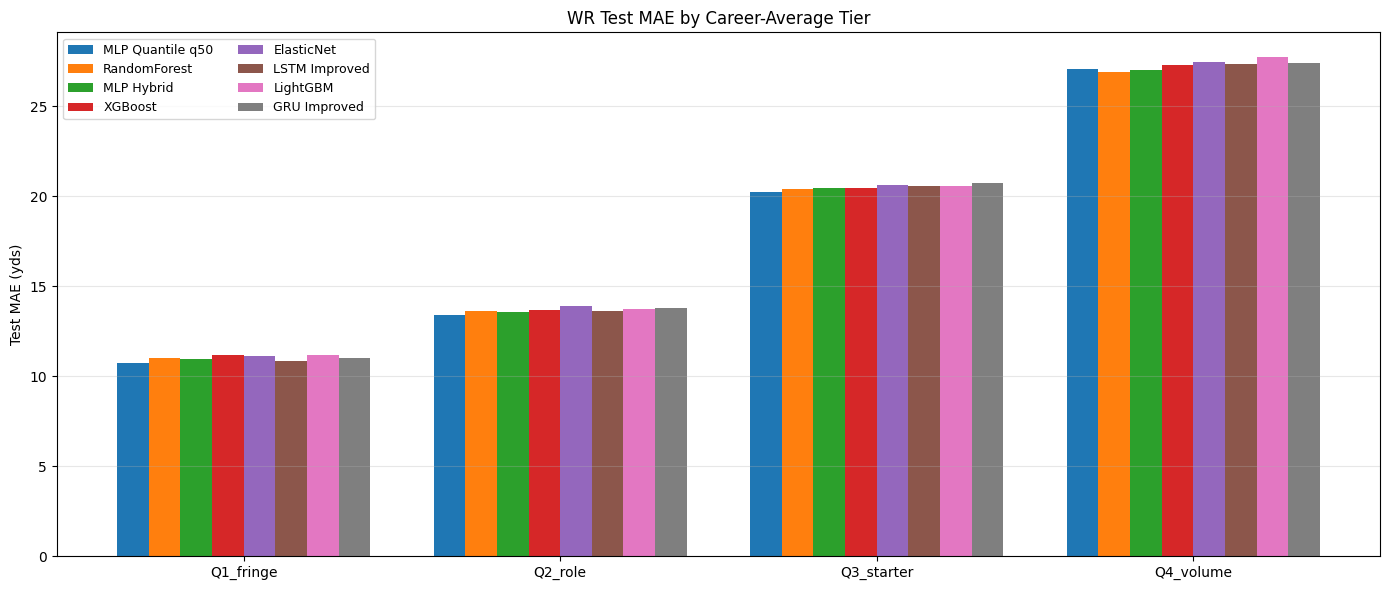

Saved: results/wr_ceiling_per_tier.png


In [15]:
# Per-tier evaluation on the test set.
# Tier is assigned from trailing_career_avg (computed above).
# Tabular models: use aligned test_df['tier'] with per-row predictions.
# Sequence models: tier lives on sequence-aligned rows (we rebuild the mapping).

tier_order = ['Q1_fringe', 'Q2_role', 'Q3_starter', 'Q4_volume']

def per_tier_mae(tiers, y_true, y_pred):
    out = {}
    for t in tier_order:
        mask = tiers == t
        if mask.sum() == 0:
            out[t] = np.nan
            continue
        out[t] = mean_absolute_error(y_true[mask], y_pred[mask])
    out['Overall'] = mean_absolute_error(y_true, y_pred)
    out['n_samples'] = len(y_true)
    return out

# Tabular: test_df['tier'] aligns with y_test_* and all tabular predictions
test_tiers_tab = test_df['tier'].values
tier_rows = []
for name in ['RandomForest', 'XGBoost', 'LightGBM', 'ElasticNet',
             'MLP Hybrid', 'MLP Quantile q50']:
    p = predictions[name]['test']
    r = per_tier_mae(test_tiers_tab, y_test_main, p)
    tier_rows.append({'Model': name, **{k: round(v, 3) if isinstance(v, float) and not np.isnan(v) else v for k, v in r.items()}})

# Sequence: align tier to sequence samples (drops first game per player)
tier_aligned_seq = []
for pid, group in df_seq.groupby('receiver_player_id'):
    group = group.sort_values(['season', 'week'])
    if len(group) < 2:
        continue
    tier_aligned_seq.extend(model_df.loc[group.index, 'tier'].values[1:])
tier_aligned_seq = np.array(tier_aligned_seq)
test_tiers_seq = tier_aligned_seq[te]

for name in ['LSTM Improved', 'GRU Improved']:
    p = predictions[name]['test_seq']
    y = predictions[name]['y_test_seq']
    r = per_tier_mae(test_tiers_seq, y, p)
    tier_rows.append({'Model': name, **{k: round(v, 3) if isinstance(v, float) and not np.isnan(v) else v for k, v in r.items()}})

tier_df = pd.DataFrame(tier_rows)
# Reorder columns
col_order = ['Model'] + tier_order + ['Overall', 'n_samples']
tier_df = tier_df[[c for c in col_order if c in tier_df.columns]]
tier_df = tier_df.sort_values('Overall').reset_index(drop=True)
print('=== Per-tier test MAE ===')
print(tier_df.to_string(index=False))

os.makedirs('../results', exist_ok=True)
tier_df.to_csv('../results/wr_ceiling_per_tier.csv', index=False)
print()
print('Saved: results/wr_ceiling_per_tier.csv')


# --- Grouped bar plot: per-tier MAE per model ---
plot_models = tier_df['Model'].tolist()
x = np.arange(len(tier_order))
width = 0.8 / len(plot_models)

fig, ax = plt.subplots(figsize=(14, 6))
for i, m in enumerate(plot_models):
    vals = [tier_df.loc[tier_df['Model'] == m, t].values[0] for t in tier_order]
    ax.bar(x + i * width - 0.4 + width / 2, vals, width, label=m)

ax.set_xticks(x)
ax.set_xticklabels(tier_order, rotation=0)
ax.set_ylabel('Test MAE (yds)')
ax.set_title('WR Test MAE by Career-Average Tier')
ax.legend(loc='upper left', ncol=2, fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/wr_ceiling_per_tier.png', dpi=120)
plt.show()
print('Saved: results/wr_ceiling_per_tier.png')


---
## 10. Per-Tier Test R²

Isto razbijanje po tier-u, ali metric je **R²** umesto MAE. Interpretacija: koliko varijanse
unutar tier-a model objasnjava. Ocekujemo da Q1 (fringe) ima **najnizi R²** (target je tamo
gotovo cist sum) i Q4 (volume) da ima **najvisi R²** (tamo features najvise nose signala).

Ako je R² negativan u tier-u, model je **losiji od konstantnog proseka tog tier-a** — znak da
features u top-10 ne sadrze potrebnu diskriminaciju za tu grupu.


=== Per-tier test R² ===
           Model  Q1_fringe  Q2_role  Q3_starter  Q4_volume  Overall  n_samples
    RandomForest     0.1184   0.1334      0.0782     0.1348   0.3247       6199
      MLP Hybrid     0.1262   0.1358      0.0714     0.1328   0.3234       6199
   LSTM Improved     0.0686   0.1337      0.0761     0.1316   0.3206       6039
    GRU Improved     0.0569   0.1310      0.0703     0.1338   0.3192       6039
         XGBoost     0.1058   0.1216      0.0680     0.1100   0.3111       6199
      ElasticNet     0.1272   0.1235      0.0624     0.1055   0.3101       6199
MLP Quantile q50     0.0884   0.0813      0.0313     0.1044   0.2954       6199
        LightGBM     0.0921   0.1051      0.0554     0.0784   0.2940       6199

Saved: results/wr_ceiling_per_tier_r2.csv


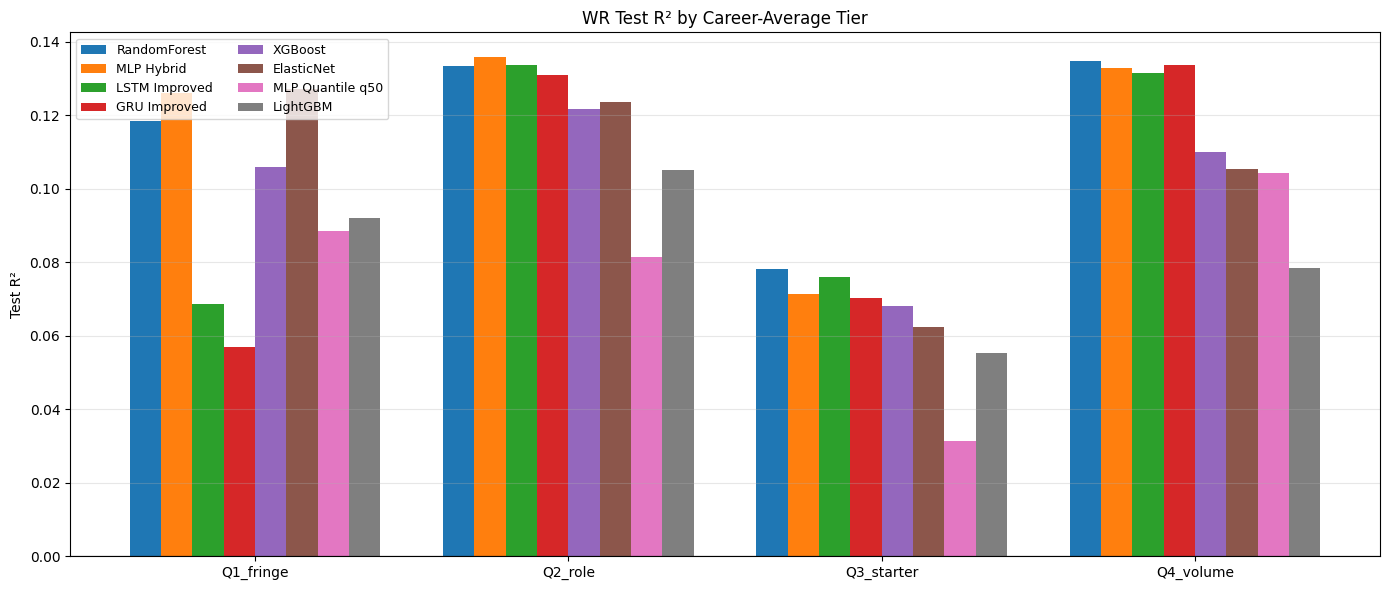

Saved: results/wr_ceiling_per_tier_r2.png


In [16]:
def per_tier_r2(tiers, y_true, y_pred):
    out = {}
    for t in tier_order:
        mask = tiers == t
        if mask.sum() == 0:
            out[t] = np.nan
            continue
        out[t] = r2_score(y_true[mask], y_pred[mask])
    out['Overall'] = r2_score(y_true, y_pred)
    out['n_samples'] = len(y_true)
    return out


r2_rows = []
for name in ['RandomForest', 'XGBoost', 'LightGBM', 'ElasticNet',
             'MLP Hybrid', 'MLP Quantile q50']:
    p = predictions[name]['test']
    r = per_tier_r2(test_tiers_tab, y_test_main, p)
    r2_rows.append({'Model': name,
                    **{k: round(v, 4) if isinstance(v, float) and not np.isnan(v) else v
                       for k, v in r.items()}})

for name in ['LSTM Improved', 'GRU Improved']:
    p = predictions[name]['test_seq']
    y = predictions[name]['y_test_seq']
    r = per_tier_r2(test_tiers_seq, y, p)
    r2_rows.append({'Model': name,
                    **{k: round(v, 4) if isinstance(v, float) and not np.isnan(v) else v
                       for k, v in r.items()}})

r2_df = pd.DataFrame(r2_rows)
col_order = ['Model'] + tier_order + ['Overall', 'n_samples']
r2_df = r2_df[[c for c in col_order if c in r2_df.columns]]
r2_df = r2_df.sort_values('Overall', ascending=False).reset_index(drop=True)
print('=== Per-tier test R² ===')
print(r2_df.to_string(index=False))

os.makedirs('../results', exist_ok=True)
r2_df.to_csv('../results/wr_ceiling_per_tier_r2.csv', index=False)
print()
print('Saved: results/wr_ceiling_per_tier_r2.csv')


# --- Grouped bar plot: per-tier R² per model ---
plot_models = r2_df['Model'].tolist()
x = np.arange(len(tier_order))
width = 0.8 / len(plot_models)

fig, ax = plt.subplots(figsize=(14, 6))
for i, m in enumerate(plot_models):
    vals = [r2_df.loc[r2_df['Model'] == m, t].values[0] for t in tier_order]
    ax.bar(x + i * width - 0.4 + width / 2, vals, width, label=m)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tier_order, rotation=0)
ax.set_ylabel('Test R²')
ax.set_title('WR Test R² by Career-Average Tier')
ax.legend(loc='upper left', ncol=2, fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/wr_ceiling_per_tier_r2.png', dpi=120)
plt.show()
print('Saved: results/wr_ceiling_per_tier_r2.png')
